In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("advertising.csv")

# Display first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [ ]:
print("Dataset Shape :", df.shape)

Dataset Shape : (200, 4)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


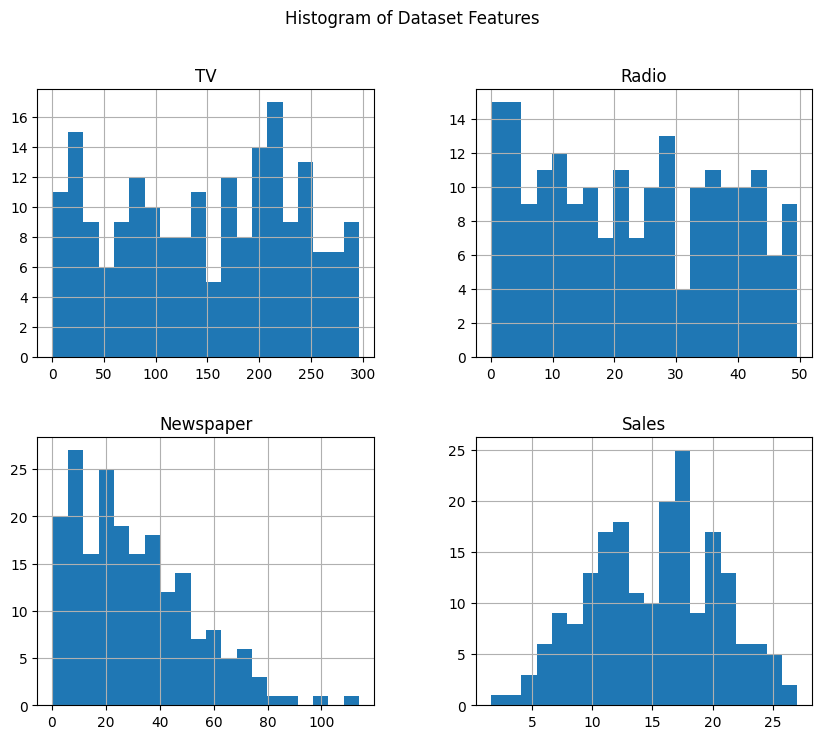

In [ ]:
# Histogram of all numerical features

df.hist(figsize=(10,8), bins=20)
plt.suptitle("Histogram of Dataset Features")
plt.show()

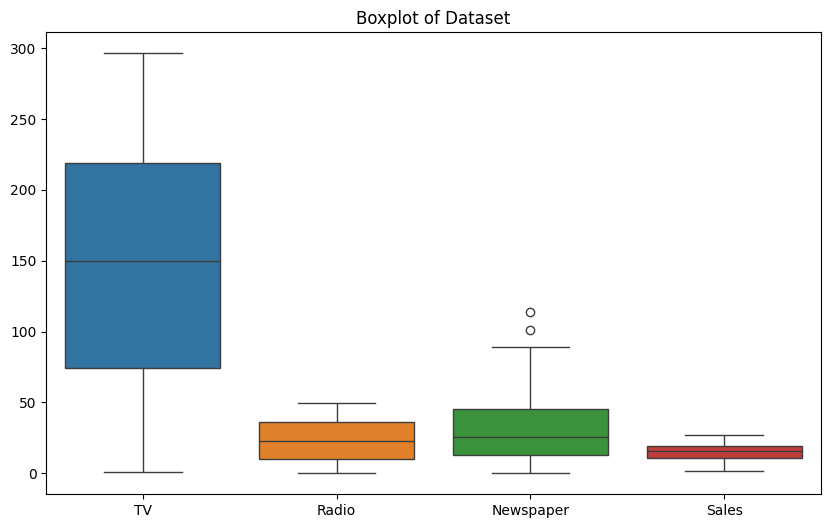

In [ ]:
# Boxplot to check for outliers

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot of Dataset")
plt.show()

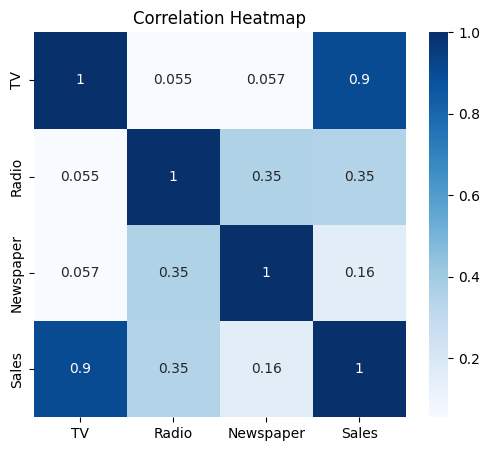

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

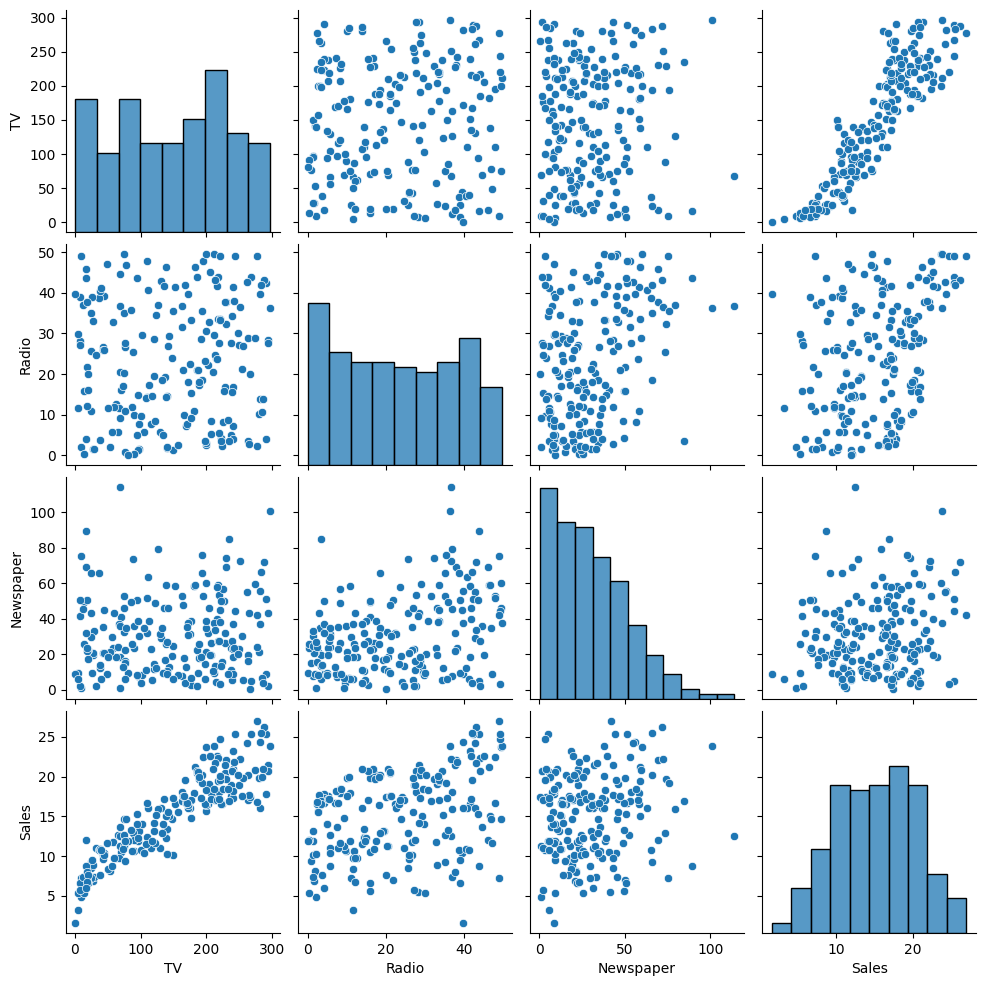

In [ ]:
# Pairplot

sns.pairplot(df)
plt.show()

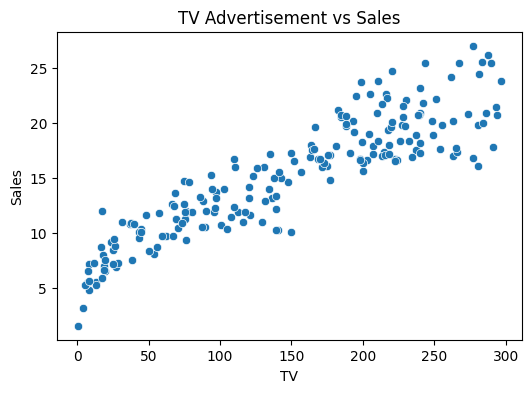

In [ ]:
# TV Advertisement vs Sales

plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertisement vs Sales")
plt.show()

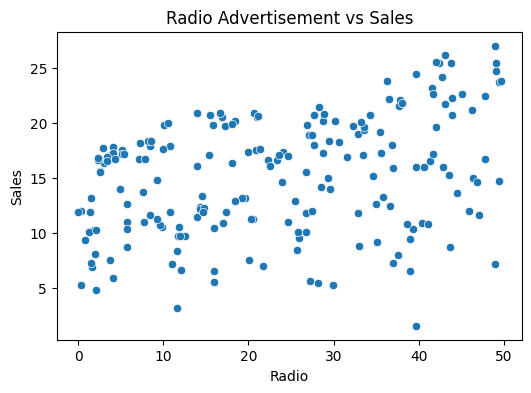

In [ ]:
# Radio Advertisement vs Sales

plt.figure(figsize=(6,4))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertisement vs Sales")
plt.show()

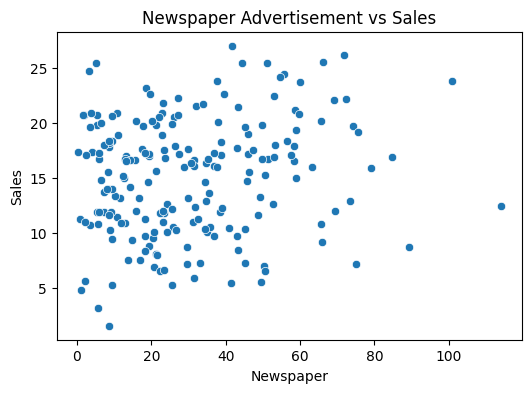

In [ ]:
# Newspaper Advertisement vs Sales

plt.figure(figsize=(6,4))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title("Newspaper Advertisement vs Sales")
plt.show()

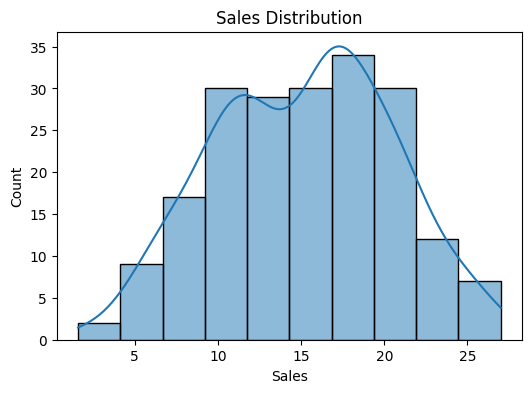

In [ ]:
# Distribution of Sales

plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

In [ ]:
# Average of each column

df.mean()

,0
TV,147.0425
Radio,23.2640
Newspaper,30.5540
Sales,15.1305


In [ ]:
# Correlation with Sales

df.corr()['Sales'].sort_values(ascending=False)

,Sales
Sales,1.000000
TV,0.901208
Radio,0.349631
Newspaper,0.157960


In [ ]:
# Features (Independent Variables)
X = df.drop('Sales', axis=1)

# Target Variable (Dependent Variable)
y = df['Sales']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (160, 3)
Testing Data Shape : (40, 3)


In [ ]:
# Create Linear Regression Model

lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

# Predict on test data
lr_pred = lr.predict(X_test)

In [ ]:
print("Linear Regression Results")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 1.2748262109549338
RMSE : 1.7052146229349223
R2 Score : 0.9059011844150826


In [ ]:
# Create Decision Tree Model

dt = DecisionTreeRegressor(random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
dt_pred = dt.predict(X_test)

In [ ]:
print("Decision Tree Results")

print("MAE :", mean_absolute_error(y_test, dt_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree Results
MAE : 1.24
RMSE : 1.8444511378727275
R2 Score : 0.8899068317956319


In [ ]:
# Create Random Forest Model

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

In [ ]:
print("Random Forest Results")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 0.9179999999999993
RMSE : 1.1989298770153327
R2 Score : 0.9534827934927883


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree',
              'Random Forest'],

    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.274826,1.705215,0.905901
1,Decision Tree,1.240000,1.844451,0.889907
2,Random Forest,0.918000,1.198930,0.953483


In [ ]:
best_model = results.sort_values(by='R2 Score', ascending=False)

print(best_model)

               Model       MAE      RMSE  R2 Score
2      Random Forest  0.918000  1.198930  0.953483
0  Linear Regression  1.274826  1.705215  0.905901
1      Decision Tree  1.240000  1.844451  0.889907


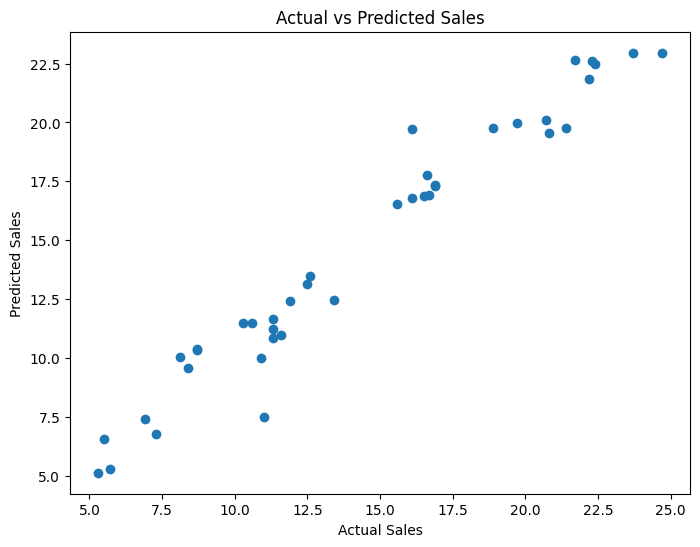

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
# Predict sales for new advertising values

new_data = pd.DataFrame({
    'TV': [150],
    'Radio': [25],
    'Newspaper': [20]
})

prediction = rf.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 14.900999999999993


In [ ]:
print("Project Conclusion")
print("------------------")
print("1. TV advertisements have the highest impact on sales.")
print("2. Radio advertisements also contribute positively.")
print("3. Newspaper advertisements have the least impact on sales.")
print("4. The model can predict future sales based on advertising budgets.")

Project Conclusion
------------------
1. TV advertisements have the highest impact on sales.
2. Radio advertisements also contribute positively.
3. Newspaper advertisements have the least impact on sales.
4. The model can predict future sales based on advertising budgets.


In [ ]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

     Feature  Importance
0         TV    0.845355
1      Radio    0.136642
2  Newspaper    0.018003


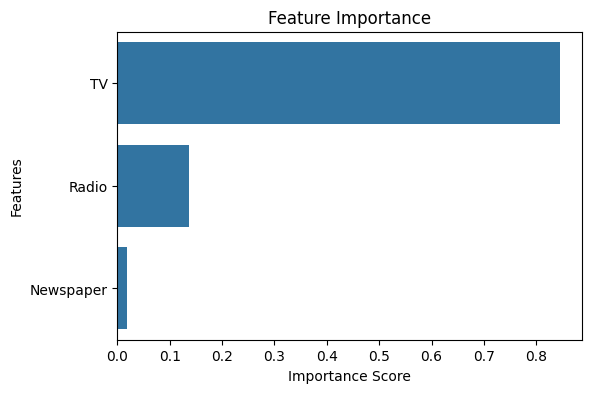

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(x='Importance', y='Feature', data=importance)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [ ]:
import joblib

# Save Random Forest Model
joblib.dump(rf, 'sales_prediction_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load('sales_prediction_model.pkl')

prediction = loaded_model.predict([[180, 30, 20]])

print("Predicted Sales:", prediction[0])

Predicted Sales: 17.79899999999999


In [ ]:
print("="*50)
print(" SALES PREDICTION USING PYTHON ")
print("="*50)

print("\nDataset Shape :", df.shape)
print("Features :", list(X.columns))

print("\nModels Used")
print("1. Linear Regression")
print("2. Decision Tree Regressor")
print("3. Random Forest Regressor")

print("\nEvaluation Metrics")
print("MAE")
print("RMSE")
print("R2 Score")

print("\nBest Model : Random Forest Regressor")
print("\nProject Completed Successfully!")

 SALES PREDICTION USING PYTHON 

Dataset Shape : (200, 4)
Features : ['TV', 'Radio', 'Newspaper']

Models Used
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

Evaluation Metrics
MAE
RMSE
R2 Score

Best Model : Random Forest Regressor

Project Completed Successfully!
